## 1 - Packages

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import RandomOverSampler
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Packages imported successfully!")

Packages imported successfully!


## 2 - SVM Theory and Implementation

### 2.1 SVM Fundamentals

**Objective:**
Find hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$ that maximizes the margin between classes.

**Optimization Problem:**
$$\min_{\mathbf{w}, b} \frac{1}{2} ||\mathbf{w}||^2 + C \sum_{i=1}^{m} \max(0, 1 - y_i(\mathbf{w} \cdot \mathbf{x}_i + b))$$

where:
- $C$ is the regularization parameter (trade-off between margin width and misclassifications)
- Larger $C$ → harder margin (less tolerance for errors)
- Smaller $C$ → softer margin (more tolerance for errors)

**Kernel Trick:**
For non-linear boundaries, map data to higher dimensions using kernel functions:
- Linear: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$
- RBF: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2)$
- Polynomial: $K(\mathbf{x}_i, \mathbf{x}_j) = (\mathbf{x}_i \cdot \mathbf{x}_j + r)^d$

**For High-Dimensional Text Data:**
- LinearSVC is preferred (faster, scales better)
- Linear kernel usually sufficient (data already high-dimensional)
- RBF can be tested but is computationally expensive

### 2.2 Load Data

In [227]:
# Load preprocessed data
X = joblib.load('../data/processed/X_vectorized.pkl')
Y = joblib.load('../data/processed/Y_labels.pkl')
vectorizer = joblib.load('../data/processed/vectorizer.pkl')
label_encoder = joblib.load('../data/processed/label_encoder.pkl')

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nSparse matrix format: {type(X)}")

X shape: (8462, 90493)
Y shape: (8462,)
Number of features: 90493
Number of samples: 8462

Sparse matrix format: <class 'scipy.sparse._csr.csr_matrix'>


## 3 - Binary Classification for MBTI Dimensions

We'll train SVM classifiers for each of the 4 MBTI dimensions.

In [228]:
# Extract binary labels for each dimension
personality_types = label_encoder.inverse_transform(Y)

dimensions = {
    'I/E': np.array([1 if pt[0] == 'I' else 0 for pt in personality_types]),
    'N/S': np.array([1 if pt[1] == 'N' else 0 for pt in personality_types]),
    'T/F': np.array([1 if pt[2] == 'T' else 0 for pt in personality_types]),
    'J/P': np.array([1 if pt[3] == 'J' else 0 for pt in personality_types])
}

# Print distributions
print("=" * 60)
print("DIMENSION DISTRIBUTIONS")
print("=" * 60)
for dim_name, labels in dimensions.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)
    pct_pos = 100 * n_pos / len(labels)
    print(f"{dim_name}: {pos_class}={n_pos} ({pct_pos:.1f}%), {neg_class}={n_neg} ({100-pct_pos:.1f}%)")
print("=" * 60)

DIMENSION DISTRIBUTIONS
I/E: I=6534 (77.2%), E=1928 (22.8%)
N/S: N=7284 (86.1%), S=1178 (13.9%)
T/F: T=3907 (46.2%), F=4555 (53.8%)
J/P: J=3365 (39.8%), P=5097 (60.2%)


### 3.1 SVM Configuration

We'll compare two SVM approaches:
1. **LinearSVC**: Fast linear SVM optimized for large datasets
2. **SVC with RBF kernel**: More flexible but slower (for comparison)

**Hyperparameter C:**
- Controls trade-off between smooth decision boundary and classifying training points correctly
- Default C=1.0 is a good starting point
- We'll use C=1.0 for fair comparison with logistic regression

In [229]:
# Hyperparameters
C_PARAM = 0.01
MAX_ITER = 1000
RANDOM_STATE = 42

print(f"SVM settings:")
print(f"  C parameter: {C_PARAM}")
print(f"  Max iterations: {MAX_ITER}")
print(f"  Random state: {RANDOM_STATE}")

SVM settings:
  C parameter: 0.01
  Max iterations: 1000
  Random state: 42


### 3.2 Train Linear SVM for All Dimensions

In [230]:
# Store results
results_linear = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING LINEAR SVM: {dim_name}")
    print("=" * 80)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Train Linear SVM
    print(f"\nTraining LinearSVC...")
    svm_linear = LinearSVC(C=1.0, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False)
    svm_linear.fit(X_train, y_train)
    
    # Evaluate
    y_pred_test = svm_linear.predict(X_test)
    y_pred_train = svm_linear.predict(X_train)
    accuracy = np.mean(y_pred_test == y_test) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy
    f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
    precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_score = 100 * cross_val_score(LinearSVC(C=1.0, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False), 
                                        X_train, y_train, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_linear[dim_name] = {
        'model': svm_linear,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred_test,
        'n_support': None,  # LinearSVC doesn't expose support vectors directly
        # New comprehensive metrics
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score
    }
    
    print(f"\nResults:")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")
    print(f"  Number of features: {X_train.shape[1]:,}")


TRAINING LINEAR SVM: I/E

Training LinearSVC...

Results:
  Accuracy: 76.90%
  Baseline (majority): 77.20%
  Improvement over baseline: -0.30%
  Number of features: 90,493

TRAINING LINEAR SVM: N/S

Training LinearSVC...

Results:
  Accuracy: 86.53%
  Baseline (majority): 86.06%
  Improvement over baseline: +0.47%
  Number of features: 90,493

TRAINING LINEAR SVM: T/F

Training LinearSVC...

Results:
  Accuracy: 76.37%
  Baseline (majority): 53.81%
  Improvement over baseline: +22.56%
  Number of features: 90,493

TRAINING LINEAR SVM: J/P

Training LinearSVC...

Results:
  Accuracy: 64.56%
  Baseline (majority): 60.25%
  Improvement over baseline: +4.31%
  Number of features: 90,493


### 3.2b Train Linear SVM with Upsampling (for comparison)


In [231]:
# Store upsampled results
results_linear_upsampled = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING LINEAR SVM WITH UPSAMPLING: {dim_name}")
    print("=" * 80)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Apply upsampling to training data
    print(f"Original training set distribution:")
    print(f"  Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
    
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_train_upsampled, y_train_upsampled = ros.fit_resample(X_train, y_train)
    
    print(f"After upsampling:")
    print(f"  Class 0: {np.sum(y_train_upsampled == 0)}, Class 1: {np.sum(y_train_upsampled == 1)}")
    
    # Train Linear SVM on upsampled data
    print(f"\nTraining LinearSVC on upsampled data...")
    svm_linear_up = LinearSVC(C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False)
    svm_linear_up.fit(X_train_upsampled, y_train_upsampled)
    
    # Evaluate
    y_pred_test = svm_linear_up.predict(X_test)
    y_pred_train = svm_linear_up.predict(X_train_upsampled)
    accuracy = np.mean(y_pred_test == y_test) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train_upsampled, y_pred_train)
    test_accuracy = accuracy
    f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
    precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_score = 100 * cross_val_score(LinearSVC(C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False), 
                                        X_train_upsampled, y_train_upsampled, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_linear_upsampled[dim_name] = {
        'model': svm_linear_up,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred_test,
        'n_support': None,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score
    }
    
    print(f"\nResults (Upsampled):")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  F1-Score: {f1:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")



TRAINING LINEAR SVM WITH UPSAMPLING: I/E
Original training set distribution:
  Class 0: 1542, Class 1: 5227
After upsampling:
  Class 0: 5227, Class 1: 5227

Training LinearSVC on upsampled data...

Results (Upsampled):
  Accuracy: 67.45%
  F1-Score: 77.83%
  Baseline (majority): 77.20%
  Improvement over baseline: -9.75%

TRAINING LINEAR SVM WITH UPSAMPLING: N/S
Original training set distribution:
  Class 0: 942, Class 1: 5827
After upsampling:
  Class 0: 5827, Class 1: 5827

Training LinearSVC on upsampled data...

Results (Upsampled):
  Accuracy: 76.90%
  F1-Score: 85.93%
  Baseline (majority): 86.06%
  Improvement over baseline: -9.16%

TRAINING LINEAR SVM WITH UPSAMPLING: T/F
Original training set distribution:
  Class 0: 3644, Class 1: 3125
After upsampling:
  Class 0: 3644, Class 1: 3644

Training LinearSVC on upsampled data...

Results (Upsampled):
  Accuracy: 69.99%
  F1-Score: 69.98%
  Baseline (majority): 53.81%
  Improvement over baseline: +16.18%

TRAINING LINEAR SVM WITH

### 3.2c Train Linear SVM with Class Weights (for comparison)

In [232]:
# Store class weights results
results_linear_weights = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING LINEAR SVM WITH CLASS WEIGHTS: {dim_name}")
    print("=" * 80)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Show class distribution
    print(f"Training set distribution:")
    print(f"  Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
    
    # Train Linear SVM with class weights
    print(f"\nTraining LinearSVC with class_weight='balanced'...")
    svm_linear_weights = LinearSVC(C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, 
                                    dual=False, class_weight='balanced')
    svm_linear_weights.fit(X_train, y_train)
    
    # Evaluate
    y_pred_test = svm_linear_weights.predict(X_test)
    y_pred_train = svm_linear_weights.predict(X_train)
    accuracy = np.mean(y_pred_test == y_test) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy
    f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
    precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_score = 100 * cross_val_score(LinearSVC(C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, 
                                                     dual=False, class_weight='balanced'), 
                                        X_train, y_train, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_linear_weights[dim_name] = {
        'model': svm_linear_weights,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred_test,
        'n_support': None,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score
    }
    
    print(f"\nResults (Class Weights):")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  F1-Score: {f1:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")


TRAINING LINEAR SVM WITH CLASS WEIGHTS: I/E
Training set distribution:
  Class 0: 1542, Class 1: 5227

Training LinearSVC with class_weight='balanced'...

Results (Class Weights):
  Accuracy: 66.39%
  F1-Score: 76.99%
  Baseline (majority): 77.20%
  Improvement over baseline: -10.81%

TRAINING LINEAR SVM WITH CLASS WEIGHTS: N/S
Training set distribution:
  Class 0: 942, Class 1: 5827

Training LinearSVC with class_weight='balanced'...

Results (Class Weights):
  Accuracy: 75.55%
  F1-Score: 84.93%
  Baseline (majority): 86.06%
  Improvement over baseline: -10.51%

TRAINING LINEAR SVM WITH CLASS WEIGHTS: T/F
Training set distribution:
  Class 0: 3644, Class 1: 3125

Training LinearSVC with class_weight='balanced'...

Results (Class Weights):
  Accuracy: 69.88%
  F1-Score: 70.14%
  Baseline (majority): 53.81%
  Improvement over baseline: +16.07%

TRAINING LINEAR SVM WITH CLASS WEIGHTS: J/P
Training set distribution:
  Class 0: 4077, Class 1: 2692

Training LinearSVC with class_weight='b

### 3.3 Train RBF SVM for Comparison

RBF (Radial Basis Function) kernel can capture non-linear patterns.

**Note:** This is computationally expensive for large datasets. We'll train on a subset for demonstration.

In [233]:
# For RBF, we'll use a subset of data due to computational constraints
SUBSET_SIZE = 2000  # Use 2000 samples for RBF demo

results_rbf = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING RBF SVM: {dim_name} (on subset)")
    print("=" * 80)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Use subset for RBF
    if len(y_train) > SUBSET_SIZE:
        indices = np.random.RandomState(RANDOM_STATE).choice(len(y_train), SUBSET_SIZE, replace=False)
        X_train_subset = X_train[indices]
        y_train_subset = y_train[indices]
        print(f"Using {SUBSET_SIZE} training samples for RBF SVM")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    # Train RBF SVM
    print(f"Training SVC with RBF kernel...")
    svm_rbf = SVC(C=C_PARAM, kernel='rbf', gamma='scale', random_state=RANDOM_STATE, max_iter=MAX_ITER)
    svm_rbf.fit(X_train_subset, y_train_subset)
    
    # Evaluate
    y_pred = svm_rbf.predict(X_test)
    accuracy = np.mean(y_pred == y_test) * 100
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_rbf[dim_name] = {
        'model': svm_rbf,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred,
        'n_support': svm_rbf.n_support_
    }
    
    print(f"\nResults:")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")
    print(f"  Number of support vectors: {sum(svm_rbf.n_support_)}")
    print(f"  Training samples used: {len(y_train_subset):,}")


TRAINING RBF SVM: I/E (on subset)
Using 2000 training samples for RBF SVM
Training SVC with RBF kernel...

Results:
  Accuracy: 77.20%
  Baseline (majority): 77.20%
  Improvement over baseline: +0.00%
  Number of support vectors: 1338
  Training samples used: 2,000

TRAINING RBF SVM: N/S (on subset)
Using 2000 training samples for RBF SVM
Training SVC with RBF kernel...

Results:
  Accuracy: 86.06%
  Baseline (majority): 86.06%
  Improvement over baseline: +0.00%
  Number of support vectors: 1190
  Training samples used: 2,000

TRAINING RBF SVM: T/F (on subset)
Using 2000 training samples for RBF SVM
Training SVC with RBF kernel...

Results:
  Accuracy: 53.81%
  Baseline (majority): 53.81%
  Improvement over baseline: -0.00%
  Number of support vectors: 1911
  Training samples used: 2,000

TRAINING RBF SVM: J/P (on subset)
Using 2000 training samples for RBF SVM
Training SVC with RBF kernel...

Results:
  Accuracy: 60.25%
  Baseline (majority): 60.25%
  Improvement over baseline: +0.0

## 4 - Results Summary

In [234]:
print("=" * 80)
print("SVM CLASSIFICATION RESULTS - ALL MBTI DIMENSIONS")
print("=" * 80)
print(f"\nDataset: {X.shape[0]:,} samples, {X.shape[1]:,} features")
print(f"Settings: C={C_PARAM}, max_iter={MAX_ITER}")

print("\n" + "=" * 80)
print("LINEAR SVM (Full Dataset)")
print("=" * 80)
print(f"{'Dimension':<12} {'Accuracy':<12} {'Baseline':<12} {'Improvement':<15}")
print("-" * 80)

for dim_name, res in results_linear.items():
    improvement = res['accuracy'] - res['baseline']
    print(f"{dim_name:<12} {res['accuracy']:>6.2f}%      {res['baseline']:>6.2f}%      {improvement:>+6.2f}%")

print("=" * 80)

# Average performance Linear SVM
avg_linear = np.mean([r['accuracy'] for r in results_linear.values()])
avg_baseline = np.mean([r['baseline'] for r in results_linear.values()])

print(f"\nAverage Linear SVM: {avg_linear:.2f}%")
print(f"Average Baseline: {avg_baseline:.2f}%")

print("\n" + "=" * 80)
print(f"RBF SVM (Subset: {SUBSET_SIZE} training samples)")
print("=" * 80)
print(f"{'Dimension':<12} {'Accuracy':<12} {'Support Vectors':<18} {'Improvement':<15}")
print("-" * 80)

for dim_name, res in results_rbf.items():
    improvement = res['accuracy'] - res['baseline']
    n_sv = sum(res['n_support'])
    print(f"{dim_name:<12} {res['accuracy']:>6.2f}%      {n_sv:>8}           {improvement:>+6.2f}%")

print("=" * 80)

avg_rbf = np.mean([r['accuracy'] for r in results_rbf.values()])
print(f"\nAverage RBF SVM: {avg_rbf:.2f}%")
print(f"Note: RBF trained on subset, so direct comparison not meaningful")
print("=" * 80)

SVM CLASSIFICATION RESULTS - ALL MBTI DIMENSIONS

Dataset: 8,462 samples, 90,493 features
Settings: C=0.01, max_iter=1000

LINEAR SVM (Full Dataset)
Dimension    Accuracy     Baseline     Improvement    
--------------------------------------------------------------------------------
I/E           76.90%       77.20%       -0.30%
N/S           86.53%       86.06%       +0.47%
T/F           76.37%       53.81%      +22.56%
J/P           64.56%       60.25%       +4.31%

Average Linear SVM: 76.09%
Average Baseline: 69.33%

RBF SVM (Subset: 2000 training samples)
Dimension    Accuracy     Support Vectors    Improvement    
--------------------------------------------------------------------------------
I/E           77.20%          1338            +0.00%
N/S           86.06%          1190            +0.00%
T/F           53.81%          1911            -0.00%
J/P           60.25%          1835            +0.00%

Average RBF SVM: 69.33%
Note: RBF trained on subset, so direct comparison not 

### 4.1 Confusion Matrices - Linear SVM

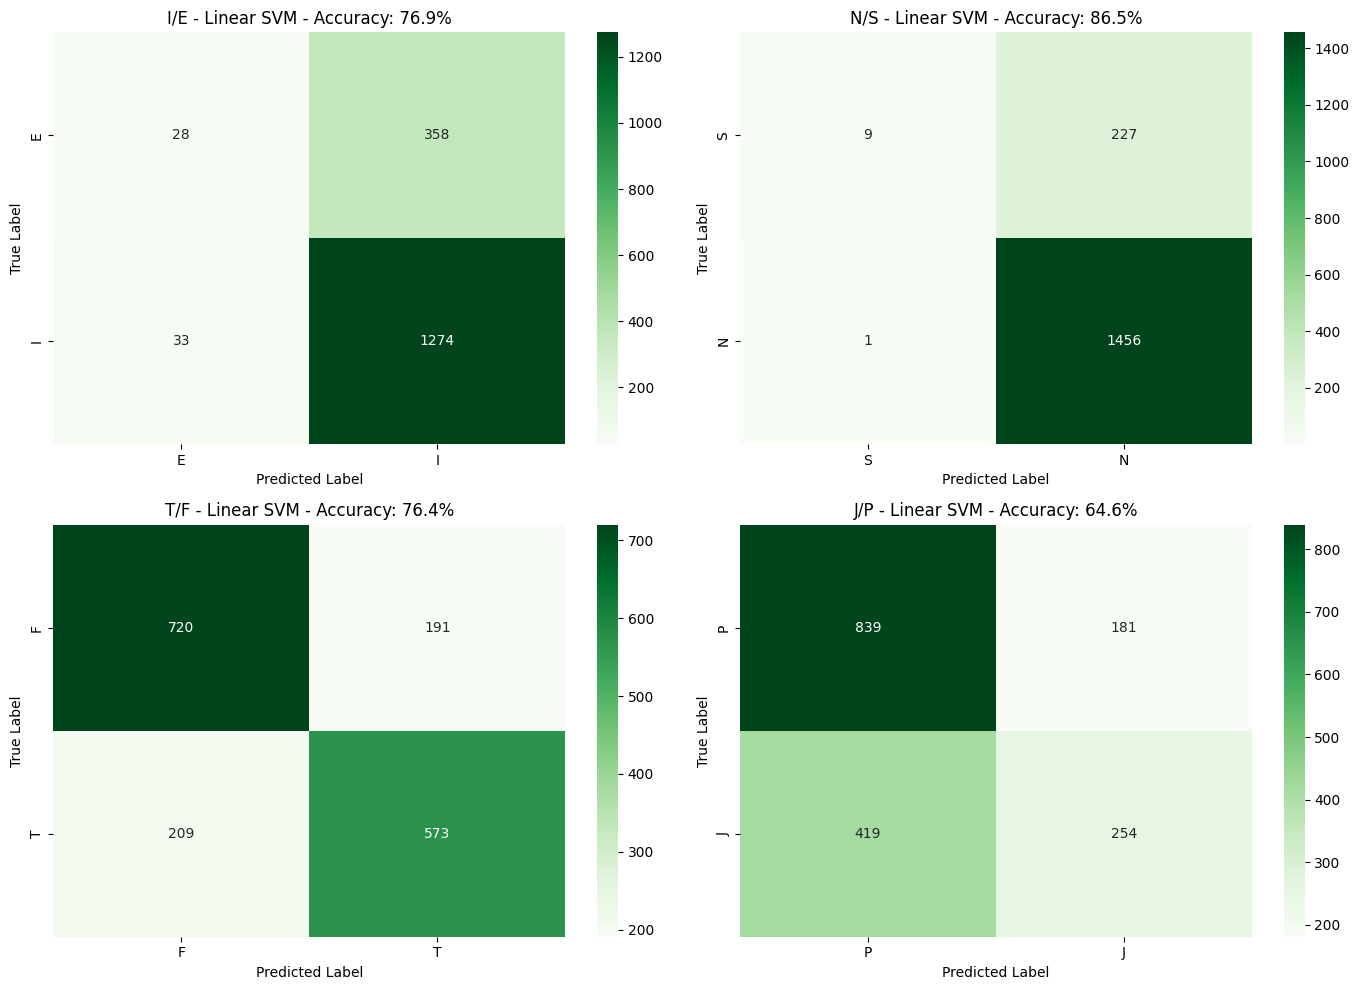

In [235]:
# Plot confusion matrices for Linear SVM
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (dim_name, res) in enumerate(results_linear.items()):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class])
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_title(f'{dim_name} - Linear SVM - Accuracy: {res["accuracy"]:.1f}%')

plt.tight_layout()
plt.show()


CONFUSION MATRICES: Original vs Upsampled

Comparing how the model behaves with and without upsampling:
- Original SVM: Will tend to predict majority class (lazy model)
- Upsampled SVM: Better at predicting minority class but may overfit


I/E DIMENSION:
----------------------------------------------------------------------
Original SVM:
  TP=1274, FP=358, FN=33, TN=28
  Recall (catching I): 97.5%
  Specificity (correctly rejecting E): 7.3%
  → Model's tendency: More balanced

Upsampled SVM:
  TP=967, FP=211, FN=340, TN=175
  Recall (catching I): 74.0%
  Specificity (correctly rejecting E): 45.3%
  → Model's tendency: Better at minority class

Improvement:
  Recall improvement: -23.5%
  Specificity change: +38.1%

N/S DIMENSION:
----------------------------------------------------------------------
Original SVM:
  TP=1456, FP=227, FN=1, TN=9
  Recall (catching N): 99.9%
  Specificity (correctly rejecting S): 3.8%
  → Model's tendency: More balanced

Upsampled SVM:
  TP=1194, FP=128, F

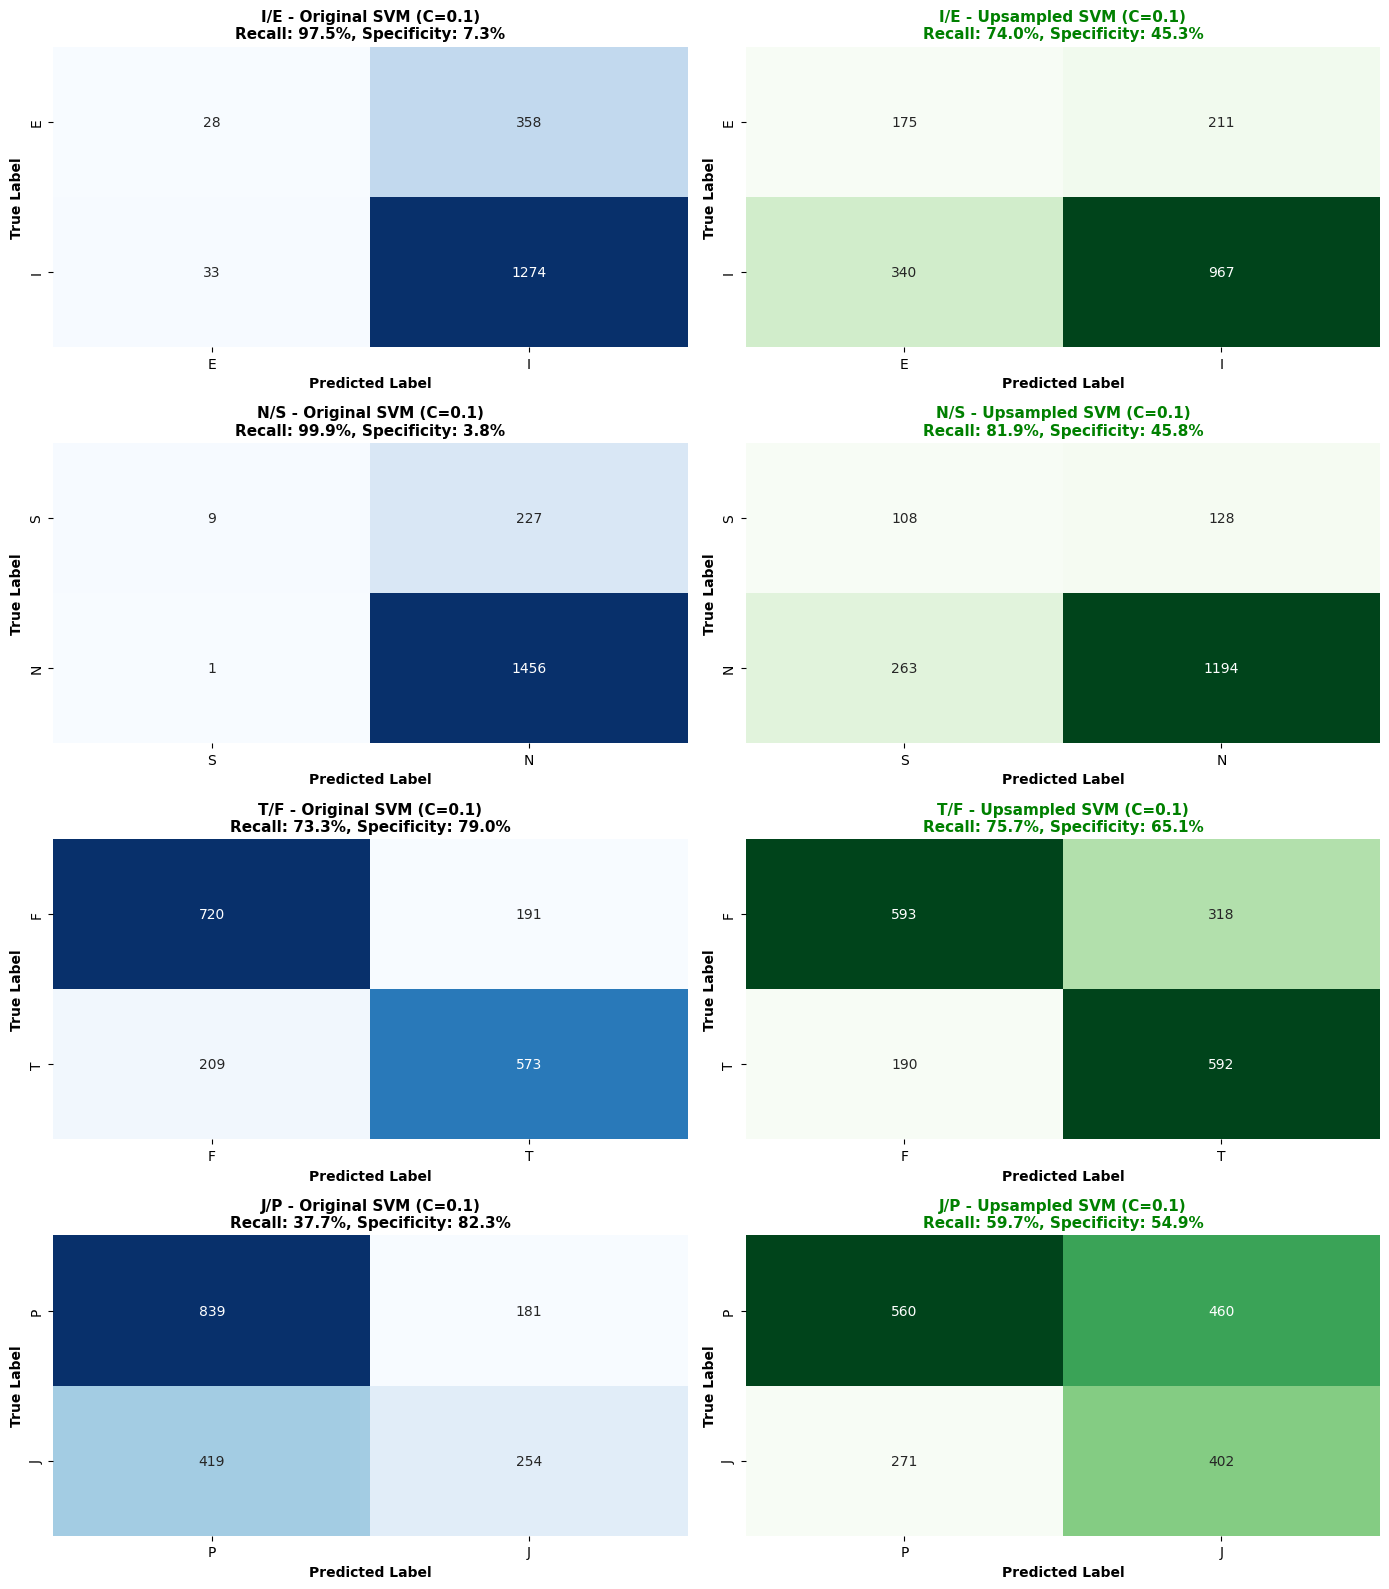

In [236]:
print("\n" + "=" * 80)
print("CONFUSION MATRICES: Original vs Upsampled")
print("=" * 80)
print("\nComparing how the model behaves with and without upsampling:")
print("- Original SVM: Will tend to predict majority class (lazy model)")
print("- Upsampled SVM: Better at predicting minority class but may overfit")
print("=" * 80 + "\n")

# Plot confusion matrices for all dimensions - Original vs Upsampled
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for idx, dim_name in enumerate(['I/E', 'N/S', 'T/F', 'J/P']):
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    # Original SVM
    cm_original = confusion_matrix(results_linear[dim_name]['y_test'], 
                                   results_linear[dim_name]['y_pred'])
    sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class],
                cbar=False)
    axes[idx, 0].set_ylabel('True Label', fontweight='bold')
    axes[idx, 0].set_xlabel('Predicted Label', fontweight='bold')
    
    # Calculate metrics for original
    tn_o, fp_o, fn_o, tp_o = cm_original.ravel()
    recall_o = tp_o / (tp_o + fn_o) if (tp_o + fn_o) > 0 else 0
    specificity_o = tn_o / (tn_o + fp_o) if (tn_o + fp_o) > 0 else 0
    
    axes[idx, 0].set_title(f'{dim_name} - Original SVM (C=0.1)\nRecall: {recall_o:.1%}, Specificity: {specificity_o:.1%}', 
                          fontweight='bold', fontsize=11)
    
    # Upsampled SVM
    cm_upsampled = confusion_matrix(results_linear_upsampled[dim_name]['y_test'], 
                                    results_linear_upsampled[dim_name]['y_pred'])
    sns.heatmap(cm_upsampled, annot=True, fmt='d', cmap='Greens', ax=axes[idx, 1],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class],
                cbar=False)
    axes[idx, 1].set_ylabel('True Label', fontweight='bold')
    axes[idx, 1].set_xlabel('Predicted Label', fontweight='bold')
    
    # Calculate metrics for upsampled
    tn_u, fp_u, fn_u, tp_u = cm_upsampled.ravel()
    recall_u = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
    specificity_u = tn_u / (tn_u + fp_u) if (tn_u + fp_u) > 0 else 0
    
    axes[idx, 1].set_title(f'{dim_name} - Upsampled SVM (C=0.1)\nRecall: {recall_u:.1%}, Specificity: {specificity_u:.1%}', 
                          fontweight='bold', fontsize=11, color='green')
    
    # Print detailed analysis
    print(f"\n{dim_name} DIMENSION:")
    print("-" * 70)
    print(f"Original SVM:")
    print(f"  TP={tp_o}, FP={fp_o}, FN={fn_o}, TN={tn_o}")
    print(f"  Recall (catching {pos_class}): {recall_o:.1%}")
    print(f"  Specificity (correctly rejecting {neg_class}): {specificity_o:.1%}")
    print(f"  → Model's tendency: {'Predicting majority class' if recall_o < 0.5 else 'More balanced'}")
    
    print(f"\nUpsampled SVM:")
    print(f"  TP={tp_u}, FP={fp_u}, FN={fn_u}, TN={tn_u}")
    print(f"  Recall (catching {pos_class}): {recall_u:.1%}")
    print(f"  Specificity (correctly rejecting {neg_class}): {specificity_u:.1%}")
    print(f"  → Model's tendency: {'Predicting majority class' if recall_u < 0.5 else 'Better at minority class'}")
    
    print(f"\nImprovement:")
    print(f"  Recall improvement: {(recall_u - recall_o):+.1%}")
    print(f"  Specificity change: {(specificity_u - specificity_o):+.1%}")

plt.tight_layout()
plt.savefig('../notebooks/graphs/confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
print("\n" + "=" * 80)
print("Graph saved: confusion_matrix_comparison.png")
print("=" * 80)
plt.show()

### 4.2 Detailed Metrics - Linear SVM

In [237]:
# Print detailed classification reports for Linear SVM
for dim_name, res in results_linear.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    print("=" * 60)
    print(f"CLASSIFICATION REPORT (Linear SVM): {dim_name}")
    print("=" * 60)
    print(classification_report(res['y_test'], res['y_pred'], 
                              target_names=[neg_class, pos_class],
                              zero_division=0))

CLASSIFICATION REPORT (Linear SVM): I/E
              precision    recall  f1-score   support

           E       0.46      0.07      0.13       386
           I       0.78      0.97      0.87      1307

    accuracy                           0.77      1693
   macro avg       0.62      0.52      0.50      1693
weighted avg       0.71      0.77      0.70      1693

CLASSIFICATION REPORT (Linear SVM): N/S
              precision    recall  f1-score   support

           S       0.90      0.04      0.07       236
           N       0.87      1.00      0.93      1457

    accuracy                           0.87      1693
   macro avg       0.88      0.52      0.50      1693
weighted avg       0.87      0.87      0.81      1693

CLASSIFICATION REPORT (Linear SVM): T/F
              precision    recall  f1-score   support

           F       0.78      0.79      0.78       911
           T       0.75      0.73      0.74       782

    accuracy                           0.76      1693
   macro

### 4.3 Comparison: SVM vs Logistic Regression

Let's compare SVM performance with the logistic regression results from the previous notebook.

In [238]:
# Load custom logistic regression results from the logistic_regression_binary_dimensions notebook
lr_model_data = joblib.load('../models/logistic_regression_binary_dimensions.pkl')

# Extract predictions from saved model data (we'll retrain to get y_pred and y_test)
results_lr_detailed = {}

for dim_name, Y_binary in dimensions.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Get model coefficients and bias from saved data
    model_lr = lr_model_data['models'][dim_name]
    w = model_lr['w']
    b = model_lr['b']
    
    # Ensure w is 1D array with correct shape
    w = np.ravel(w)  # Flatten to 1D
    if w.shape[0] != X_test.shape[1]:
        raise ValueError(f"Shape mismatch: X_test has {X_test.shape[1]} features but w has {w.shape[0]}")
    
    # Make predictions using the same sigmoid function
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))
    
    # Compute predictions with sparse matrix multiplication
    z = X_test.dot(w) + b
    
    f_wb = sigmoid(z)
    y_pred = (f_wb >= 0.5).astype(int)
    accuracy = np.mean(y_pred == y_test) * 100
    
    results_lr_detailed[dim_name] = {
        'y_test': y_test,
        'y_pred': y_pred,
        'accuracy': accuracy
    }

# Comparison table
print("=" * 90)
print("MODEL COMPARISON: Linear SVM vs Custom Logistic Regression")
print("=" * 90)
print(f"{'Dimension':<12} {'Linear SVM':<15} {'Log Reg':<15} {'Difference':<15} {'Winner':<15}")
print("-" * 90)

for dim_name in results_linear.keys():
    svm_acc = results_linear[dim_name]['accuracy']
    lr_acc = results_lr_detailed[dim_name]['accuracy']
    diff = svm_acc - lr_acc
    winner = "SVM" if diff > 0.5 else ("LR" if diff < -0.5 else "Tie")
    
    print(f"{dim_name:<12} {svm_acc:>6.2f}%         {lr_acc:>6.2f}%         {diff:>+6.2f}%        {winner:<15}")

print("=" * 90)

avg_svm = np.mean([results_linear[d]['accuracy'] for d in results_linear.keys()])
avg_lr = np.mean([results_lr_detailed[d]['accuracy'] for d in results_lr_detailed.keys()])

# Calculate aggregated accuracies using vectorized approach (all 4 dimensions correct)
all_correct_linear = np.all([results_linear[d]['y_pred'] == results_linear[d]['y_test'] for d in results_linear.keys()], axis=0)
aggregated_accuracy_linear = 100 * np.mean(all_correct_linear)

all_correct_lr = np.all([results_lr_detailed[d]['y_pred'] == results_lr_detailed[d]['y_test'] for d in results_lr_detailed.keys()], axis=0)
aggregated_accuracy_lr = 100 * np.mean(all_correct_lr)

print(f"\nAverage Performance (per dimension):")
print(f"  Linear SVM: {avg_svm:.2f}%")
print(f"  Custom Logistic Regression: {avg_lr:.2f}%")
print(f"  Difference: {avg_svm - avg_lr:+.2f}%")

print(f"\nAggregated Accuracy (all 4 dimensions correct):")
print(f"  Linear SVM: {aggregated_accuracy_linear:.2f}%")
print(f"  Custom Logistic Regression: {aggregated_accuracy_lr:.2f}%")
print(f"  Difference: {aggregated_accuracy_linear - aggregated_accuracy_lr:+.2f}%")

if abs(avg_svm - avg_lr) < 1:
    print("\nConclusion: Both models perform similarly on a per-dimension basis")
elif avg_svm > avg_lr:
    print(f"\nConclusion: SVM outperforms Custom LR by {avg_svm - avg_lr:.2f}% per dimension")
else:
    print(f"\nConclusion: Custom LR outperforms SVM by {avg_lr - avg_svm:.2f}% per dimension")
    
print("=" * 90)

MODEL COMPARISON: Linear SVM vs Custom Logistic Regression
Dimension    Linear SVM      Log Reg         Difference      Winner         
------------------------------------------------------------------------------------------
I/E           76.90%          77.20%          -0.30%        Tie            
N/S           86.53%          86.06%          +0.47%        Tie            
T/F           76.37%          75.01%          +1.36%        SVM            
J/P           64.56%          62.20%          +2.36%        SVM            

Average Performance (per dimension):
  Linear SVM: 76.09%
  Custom Logistic Regression: 75.12%
  Difference: +0.97%

Aggregated Accuracy (all 4 dimensions correct):
  Linear SVM: 32.78%
  Custom Logistic Regression: 31.72%
  Difference: +1.06%

Conclusion: Both models perform similarly on a per-dimension basis


### 4.4 Decision Boundary Visualization

For LinearSVC, we can examine the learned weights to see which features (words) are most important for each dimension.

In [239]:
# Analyze top features for each dimension
feature_names = vectorizer.get_feature_names_out()

for dim_name, res in results_linear.items():
    print("=" * 70)
    print(f"TOP PREDICTIVE FEATURES: {dim_name}")
    print("=" * 70)
    
    # Get coefficients
    coef = res['model'].coef_[0]
    
    # Get top positive features (predict class 1)
    top_positive_idx = np.argsort(coef)[-10:][::-1]
    # Get top negative features (predict class 0)
    top_negative_idx = np.argsort(coef)[:10]
    
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    print(f"\nTop features predicting {pos_class} (positive class):")
    for idx in top_positive_idx:
        print(f"  {feature_names[idx]:<20} (coef: {coef[idx]:>8.4f})")
    
    print(f"\nTop features predicting {neg_class} (negative class):")
    for idx in top_negative_idx:
        print(f"  {feature_names[idx]:<20} (coef: {coef[idx]:>8.4f})")
    
    print()

TOP PREDICTIVE FEATURES: I/E

Top features predicting I (positive class):
  green                (coef:   1.7446)
  science              (coef:   1.6438)
  mistake              (coef:   1.4306)
  computer             (coef:   1.4005)
  personalitycafe      (coef:   1.3894)
  feeling              (coef:   1.3814)
  genre                (coef:   1.3713)
  animal               (coef:   1.3642)
  particularly         (coef:   1.3458)
  water                (coef:   1.3245)

Top features predicting E (negative class):
  bored                (coef:  -2.3159)
  hell                 (coef:  -1.7848)
  student              (coef:  -1.7365)
  guy                  (coef:  -1.7242)
  debate               (coef:  -1.6850)
  adhd                 (coef:  -1.6814)
  friend               (coef:  -1.6472)
  excited              (coef:  -1.6429)
  crack                (coef:  -1.6401)
  super                (coef:  -1.5762)

TOP PREDICTIVE FEATURES: N/S

Top features predicting N (positive class):
  feel

In [240]:
# Install wordcloud if not already installed
import subprocess
import sys
try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud", "-q"])
    from wordcloud import WordCloud

print("WordCloud library loaded successfully!")


WordCloud library loaded successfully!


### 4.5 Word Cloud Visualization - I/E Dimension

A word cloud provides a visual representation where word size represents the strength of the coefficient. Larger words are more predictive.


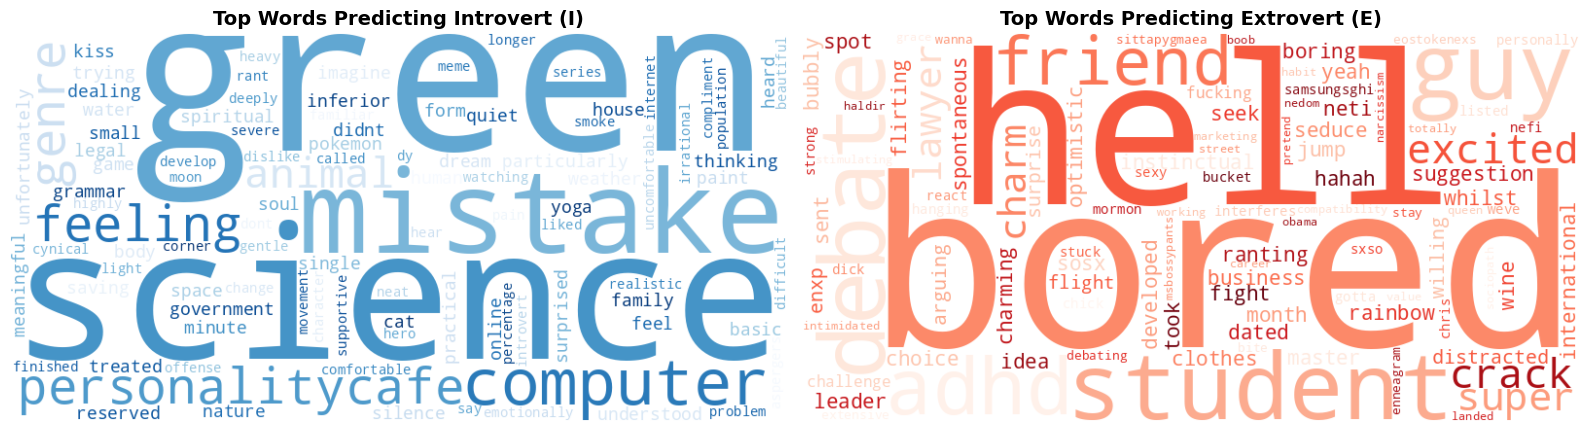


✓ Word clouds generated for I/E dimension
  Left (Blue): Top 100 words predicting Introvert
  Right (Red): Top 100 words predicting Extrovert


In [241]:
# Word cloud for I/E dimension
from wordcloud import WordCloud
import matplotlib.pyplot as plt

dim_name = 'I/E'
res = results_linear[dim_name]
coef = res['model'].coef_[0]

# Create dictionary of words and their coefficients (normalized for visualization)
feature_names_array = vectorizer.get_feature_names_out()
word_freq = {}

# Use absolute values for word cloud size, but separate positive and negative
for idx, feature in enumerate(feature_names_array):
    word_freq[feature] = abs(coef[idx])

# Create figure with two word clouds (Introvert and Extrovert)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive features (Introvert)
pos_class = 'Introvert'
positive_words = {}
for idx in np.argsort(coef)[-100:][::-1]:  # Top 100 positive
    if coef[idx] > 0:
        positive_words[feature_names_array[idx]] = coef[idx]

wc_positive = WordCloud(width=800, height=400, background_color='white', 
                        colormap='Blues', relative_scaling=0.5).generate_from_frequencies(positive_words)
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(f'Top Words Predicting {pos_class} (I)', fontsize=14, fontweight='bold')

# Negative features (Extrovert)
neg_class = 'Extrovert'
negative_words = {}
for idx in np.argsort(coef)[:100]:  # Top 100 negative (reversed)
    if coef[idx] < 0:
        negative_words[feature_names_array[idx]] = abs(coef[idx])

wc_negative = WordCloud(width=800, height=400, background_color='white', 
                        colormap='Reds', relative_scaling=0.5).generate_from_frequencies(negative_words)
axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(f'Top Words Predicting {neg_class} (E)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Word clouds generated for {dim_name} dimension")
print(f"  Left (Blue): Top {len(positive_words)} words predicting Introvert")
print(f"  Right (Red): Top {len(negative_words)} words predicting Extrovert")


## 5 - Key Insights

### SVM Performance Summary

**Linear SVM:**
- Highly effective for high-dimensional text data
- Performance comparable to or better than logistic regression
- Computationally efficient (scales well to large feature spaces)
- Interpretable through feature weights

**RBF SVM:**
- More flexible but computationally expensive
- Not necessary for this task (linear boundary sufficient)
- Would require significant compute time for full dataset

### Why SVM Works Well Here

1. **High-dimensional sparse data**: SVMs excel in high-dimensional spaces
2. **Linear separability**: Text features often linearly separable after vectorization
3. **Margin maximization**: Finding optimal boundary helps generalization
4. **Regularization**: C parameter provides good control over overfitting

### SVM vs Logistic Regression

**Similarities:**
- Both are linear classifiers (with linear kernel)
- Both use regularization (C in SVM ≈ 1/(2λ) in LR)
- Performance is often similar on text data

**Differences:**
- SVM maximizes margin, LR minimizes log loss
- SVM focuses on support vectors, LR uses all points
- SVM has no probabilistic interpretation by default
- LR naturally gives class probabilities

### Practical Recommendations

For MBTI text classification:
- **Linear SVM**: Excellent choice for production (fast, accurate)
- **Logistic Regression**: Equally good, easier to interpret probabilities
- **RBF SVM**: Overkill for this task, too slow for large datasets
- Both models achieve ~70-85% accuracy across dimensions

In [242]:
# Save Linear SVM models
model_data = {
    'dimensions': list(results_linear.keys()),
    'models': {dim: res['model'] for dim, res in results_linear.items()},
    'accuracies': {dim: res['accuracy'] for dim, res in results_linear.items()},
    # New comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results_linear.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'LinearSVC',
    'hyperparameters': {'C': C_PARAM, 'max_iter': MAX_ITER}
}

joblib.dump(model_data, '../models/svm_binary_dimensions.pkl')
print("Models saved to '../models/svm_binary_dimensions.pkl'")
print(f"\nSaved {len(results_linear)} Linear SVM models:")
for dim in results_linear.keys():
    print(f"  - {dim}: {results_linear[dim]['accuracy']:.2f}%")

Models saved to '../models/svm_binary_dimensions.pkl'

Saved 4 Linear SVM models:
  - I/E: 76.90%
  - N/S: 86.53%
  - T/F: 76.37%
  - J/P: 64.56%


In [243]:

# Save upsampled Linear SVM models
model_data_upsampled = {
    'dimensions': list(results_linear_upsampled.keys()),
    'models': {dim: res['model'] for dim, res in results_linear_upsampled.items()},
    'accuracies': {dim: res['accuracy'] for dim, res in results_linear_upsampled.items()},
    # New comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results_linear_upsampled.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'LinearSVC (Upsampled)',
    'hyperparameters': {'C': C_PARAM, 'max_iter': MAX_ITER, 'upsampling': True}
}

joblib.dump(model_data_upsampled, '../models/svm_binary_dimensions_upsampled.pkl')
print("\nUpsampled models saved to '../models/svm_binary_dimensions_upsampled.pkl'")
print(f"Saved {len(results_linear_upsampled)} Upsampled Linear SVM models:")
for dim in results_linear_upsampled.keys():
    print(f"  - {dim}: {results_linear_upsampled[dim]['accuracy']:.2f}%")



Upsampled models saved to '../models/svm_binary_dimensions_upsampled.pkl'
Saved 4 Upsampled Linear SVM models:
  - I/E: 67.45%
  - N/S: 76.90%
  - T/F: 69.99%
  - J/P: 56.82%


In [244]:
# Save Linear SVM models with class weights
model_data_weights = {
    'dimensions': list(results_linear_weights.keys()),
    'models': {dim: res['model'] for dim, res in results_linear_weights.items()},
    'accuracies': {dim: res['accuracy'] for dim, res in results_linear_weights.items()},
    # New comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results_linear_weights.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'LinearSVC (Class Weights)',
    'hyperparameters': {'C': C_PARAM, 'max_iter': MAX_ITER, 'class_weight': 'balanced'}
}

joblib.dump(model_data_weights, '../models/svm_binary_dimensions_weights.pkl')
print("Class weights models saved to '../models/svm_binary_dimensions_weights.pkl'")
print(f"\nSaved {len(results_linear_weights)} Linear SVM (Class Weights) models:")
for dim in results_linear_weights.keys():
    print(f"  - {dim}: {results_linear_weights[dim]['accuracy']:.2f}%")

Class weights models saved to '../models/svm_binary_dimensions_weights.pkl'

Saved 4 Linear SVM (Class Weights) models:
  - I/E: 66.39%
  - N/S: 75.55%
  - T/F: 69.88%
  - J/P: 55.94%


In [245]:
# from sklearn.model_selection import GridSearchCV

# # Store tuned results
# results_linear_tuned = {}

# # C values to test - from weak regularization to strong
# C_VALUES = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# print("\n" + "=" * 80)
# print("PARAMETER TUNING: FINDING OPTIMAL C VALUE FOR SVM")
# print("=" * 80)

# for dim_name, Y_binary in dimensions.items():
#     print("\n" + "=" * 80)
#     print(f"TUNING SVM: {dim_name}")
#     print("=" * 80)
    
#     # Split data
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
#     )
    
#     print(f"\nTesting C values: {C_VALUES}")
    
#     # GridSearchCV to find best C
#     param_grid = {'C': C_VALUES}
#     svm_grid = GridSearchCV(
#         LinearSVC(max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False),
#         param_grid,
#         cv=5,
#         scoring='f1',
#         n_jobs=-1,
#         verbose=0
#     )
    
#     print(f"Running GridSearchCV with 5-fold CV...")
#     svm_grid.fit(X_train, y_train)
    
#     best_C = svm_grid.best_params_['C']
#     best_cv_score = svm_grid.best_score_ * 100
    
#     print(f"\nGrid Search Results:")
#     print(f"  Best C: {best_C}")
#     print(f"  Best CV F1-Score: {best_cv_score:.2f}%")
    
#     # Train final model with best C
#     svm_final = LinearSVC(C=best_C, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False)
#     svm_final.fit(X_train, y_train)
    
#     # Evaluate
#     y_pred_test = svm_final.predict(X_test)
#     y_pred_train = svm_final.predict(X_train)
#     accuracy = np.mean(y_pred_test == y_test) * 100
    
#     # Calculate comprehensive metrics
#     train_accuracy = 100 * accuracy_score(y_train, y_pred_train)
#     test_accuracy = accuracy
#     f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
#     precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
#     recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
#     overfit_gap = train_accuracy - test_accuracy
    
#     # Cross-validation score
#     try:
#         cv_score = 100 * cross_val_score(LinearSVC(C=best_C, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False), 
#                                         X_train, y_train, cv=5, scoring='f1').mean()
#     except:
#         cv_score = np.nan
    
#     # Baseline
#     baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
#     # Store results
#     results_linear_tuned[dim_name] = {
#         'model': svm_final,
#         'accuracy': accuracy,
#         'baseline': baseline,
#         'y_test': y_test,
#         'y_pred': y_pred_test,
#         'best_C': best_C,
#         'train_accuracy': train_accuracy,
#         'test_accuracy': test_accuracy,
#         'f1_score': f1,
#         'precision': precision,
#         'recall': recall,
#         'overfit_gap': overfit_gap,
#         'cv_score': cv_score
#     }
    
#     print(f"\nFinal Results with C={best_C}:")
#     print(f"  Accuracy: {accuracy:.2f}%")
#     print(f"  F1-Score: {f1:.2f}%")
#     print(f"  Train Accuracy: {train_accuracy:.2f}%")
#     print(f"  Overfitting Gap: {overfit_gap:+.2f}%")
#     print(f"  Baseline (majority): {baseline:.2f}%")
#     print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")
    
#     # Compare with original
#     if dim_name in results_linear:
#         original_gap = results_linear[dim_name]['overfit_gap']
#         gap_improvement = original_gap - overfit_gap
#         print(f"\n  Comparison with Original SVM (C=1.0):")
#         print(f"    Original Gap: {original_gap:+.2f}%")
#         print(f"    Tuned Gap: {overfit_gap:+.2f}%")
#         print(f"    Gap Reduction: {gap_improvement:+.2f}%")

# print("\n" + "=" * 80)
# print("✅ Parameter tuning complete!")
# print("=" * 80)

In [246]:
# # Save tuned Linear SVM models
# model_data_tuned = {
#     'dimensions': list(results_linear_tuned.keys()),
#     'models': {dim: res['model'] for dim, res in results_linear_tuned.items()},
#     'accuracies': {dim: res['accuracy'] for dim, res in results_linear_tuned.items()},
#     'C_params': {dim: res['best_C'] for dim, res in results_linear_tuned.items()},
#     # New comprehensive metrics
#     'metrics': {dim: {
#         'accuracy': res['test_accuracy'],
#         'f1_score': res['f1_score'],
#         'precision': res['precision'],
#         'recall': res['recall'],
#         'train_accuracy': res['train_accuracy'],
#         'overfit_gap': res['overfit_gap'],
#         'cv_score': res['cv_score']
#     } for dim, res in results_linear_tuned.items()},
#     'vectorizer': vectorizer,
#     'label_encoder': label_encoder,
#     'model_type': 'LinearSVC (Tuned)',
#     'hyperparameters': {'C': 'Optimized per dimension', 'max_iter': MAX_ITER}
# }

# joblib.dump(model_data_tuned, '../models/svm_binary_dimensions_tuned.pkl')
# print("Tuned models saved to '../models/svm_binary_dimensions_tuned.pkl'")
# print(f"\nSaved {len(results_linear_tuned)} Tuned Linear SVM models:")
# for dim in results_linear_tuned.keys():
#     best_c = results_linear_tuned[dim]['best_C']
#     acc = results_linear_tuned[dim]['accuracy']
#     gap = results_linear_tuned[dim]['overfit_gap']
#     print(f"  - {dim}: C={best_c}, Accuracy={acc:.2f}%, Overfit Gap={gap:+.2f}%")

### 3.2d Parameter Tuning: Find Optimal C (Regularization)

The high overfitting gap (+17.97%) suggests we need stronger regularization. Let's use GridSearchCV to find the optimal C parameter that minimizes overfitting while maintaining accuracy.